# Milestone 1 - Signal Acquisition & Measurement-Based Synthesis

**TH Köln · ddmo-sose-26 · Mayank, Ravi, Anwar**

This notebook runs the **complete Milestone 1 pipeline** on the full appliance set
(original lab batch + the new live-lab measurements), end-to-end. Press **Run All**.

It uses the `src/nilm/` package modules:

| Module | Role |
|--------|------|
| `registry` | Discovers appliances by scanning `data/raw/` (data-driven, no hardcoded lists); robust loader |
| `acquisition` | Preprocess + fingerprint each appliance |
| `synthesizer` | Generate 150 train + 50 test synthetic runs per appliance |
| `verification` | Prove synthetic matches real (mean + noise band tests) |
| `visualization` | Per-device 6-channel plots |

**Data-driven:** drop a new PAC4200 CSV into `data/raw/` and it appears automatically.
PV is auto-excluded from the classifier set (it is generation, not a switching load);
it stays available for Milestone 3.


## 0. Setup

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

%load_ext autoreload
%autoreload 2
%matplotlib inline

import pandas as pd
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)

from nilm import registry, acquisition, synthesizer, verification, visualization, paths
paths.ensure_dirs()

print("Appliances discovered for classification (PV excluded):")
classif = registry.discover()
for d, p in classif.items():
    print(f"  {d:24s} <- {p.name}")
excluded = set(registry.discover(include_excluded=True)) - set(classif)
print()
print(f"Excluded (reserved for M3): {sorted(excluded)}")

REGENERATE_SYNTHETIC = True   # set False to reuse existing synthetic data


Appliances discovered for classification (PV excluded):
  COFFEE_MACHINE           <- COFFEE_MACHINE_001.csv
  COOLER_FAN1              <- COOLER_FAN1_001.csv
  CPU                      <- CPU_001.csv
  FLOUROSCENT_LAMP         <- FLOUROSCENT_LAMP_001.csv
  INCENDESCENT_LIGHT       <- INCENDESCENT_LIGHT_001.csv
  Laptop                   <- Laptop_001.csv
  Monitor                  <- Monitor_001.csv
  TABLE_FAN                <- TABLE_FAN_001.csv
  WATER_HEATER             <- WATER_HEATER_001.csv
  Foen Stufe 1             <- pac4200_foen_stufe1_200ms.csv
  LED Lampe 6.3 W          <- pac4200_led_lampe_6p3w_200ms.csv
  Leuchtstoffroehre        <- pac4200_leuchtstoffroehre_200ms.csv
  Mixer                    <- pac4200_mixer_200ms.csv
  Toaster                  <- pac4200_toaster_200ms.csv
  USB Ladegerät            <- pac4200_usb_ladegeraet_200ms.csv

Excluded (reserved for M3): ['PV']


## 1. Acquisition & Understanding

Each appliance is loaded robustly (blank rows dropped, device names cleaned), its main
ON region is detected, and a measured **fingerprint** is extracted. The number of on/off
**cycles** per recording is also reported - the new lab files cycle multiple times, which
later gives many more real test samples than one per appliance.


In [2]:
summary, fingerprints = acquisition.build_stage1()
summary

,Device,Peak_W,On_P_W,On_Q_var,PF,THD_i_%,Cycles,Character
0,Toaster,1509.3,1397.475,2.756,0.996,2.658,1,resistive
1,COFFEE_MACHINE,1354.2,1215.460,2.448,1.000,2.037,2,resistive
2,WATER_HEATER,958.6,955.017,2.623,0.999,1.819,2,resistive
3,INCENDESCENT_LIGHT,659.3,502.653,-0.165,0.998,1.810,2,resistive
4,Foen Stufe 1,146.9,138.165,-9.285,0.899,47.262,1,non-linear
5,Laptop,64.8,46.283,-9.269,0.464,180.170,3,non-linear
6,Leuchtstoffroehre,40.0,38.183,78.267,0.436,10.597,1,inductive
7,FLOUROSCENT_LAMP,40.5,36.809,97.133,0.353,9.000,2,inductive
8,COOLER_FAN1,35.4,30.495,48.040,0.531,11.642,4,inductive
9,Monitor,18.1,17.943,-3.018,0.504,165.544,2,non-linear


**Reading the table:**

- Four large **resistive** loads (Toaster, Coffee Machine, Water Heater, Incandescent) -
  PF≈1, low THD, separated mainly by power level.
- One **inductive** group (both fluorescents, Cooler Fan, Table Fan) - positive reactive power.
- A dense **electronic** group (Laptop, Monitor, CPU, USB, LED, Mixer) - high current THD,
  all in a tight low-power band.

Two genuinely hard pairs to watch in Milestone 2: the **two fluorescents**
(Leuchtstoffröhre vs Fluorescent Lamp, ~38 W both, inductive) and **CPU vs USB**
(~9.5 W both, THD ~160%). These look almost identical electrically.


## 2. Per-Device Visualizations

Each appliance across six channels (P, Q, PF, THD_i, current, voltage). This is where the
electrical character of each device is visible - the resistive step of the toaster, the
two-speed mixer, the cycling of the fans and water heater, the distorted current of the
electronic loads.


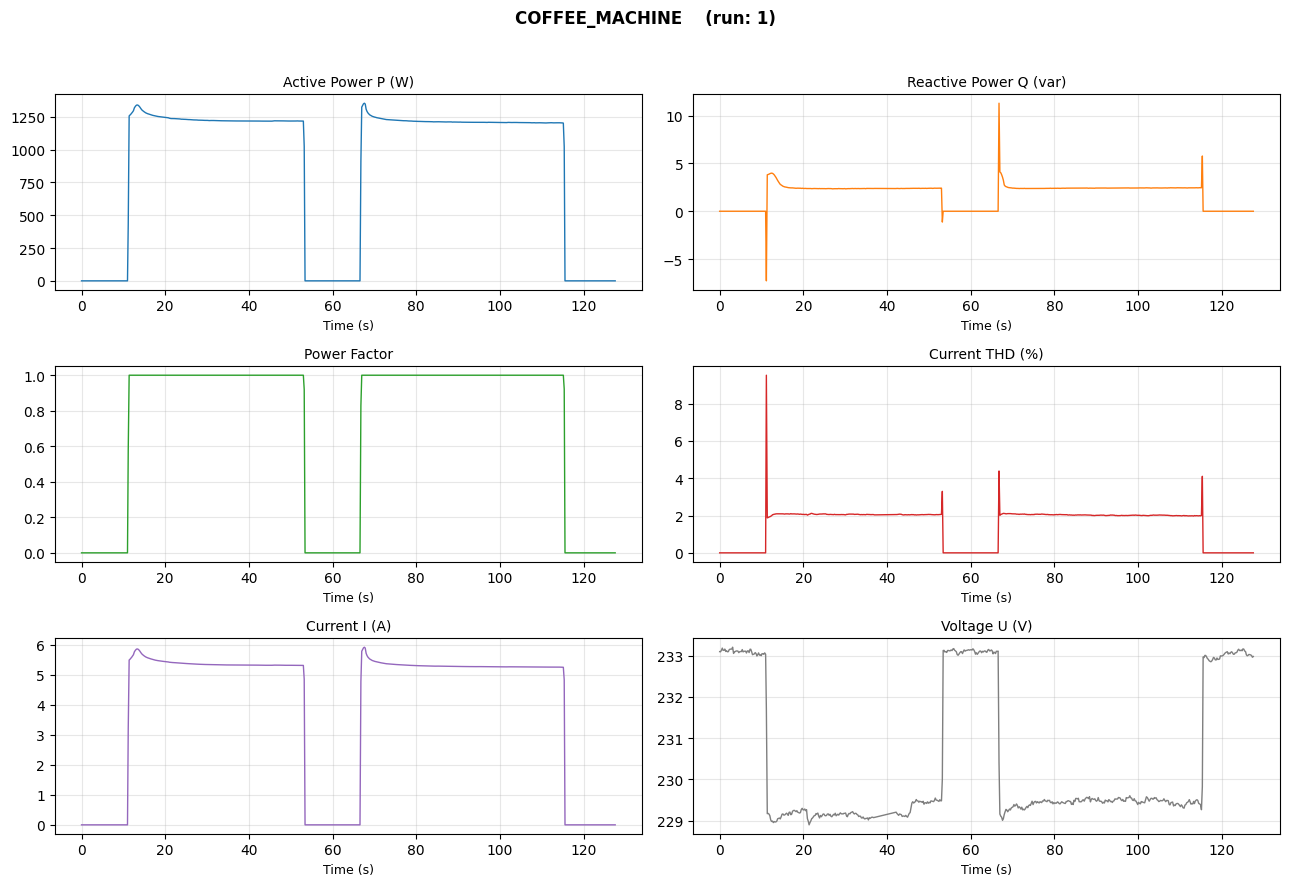

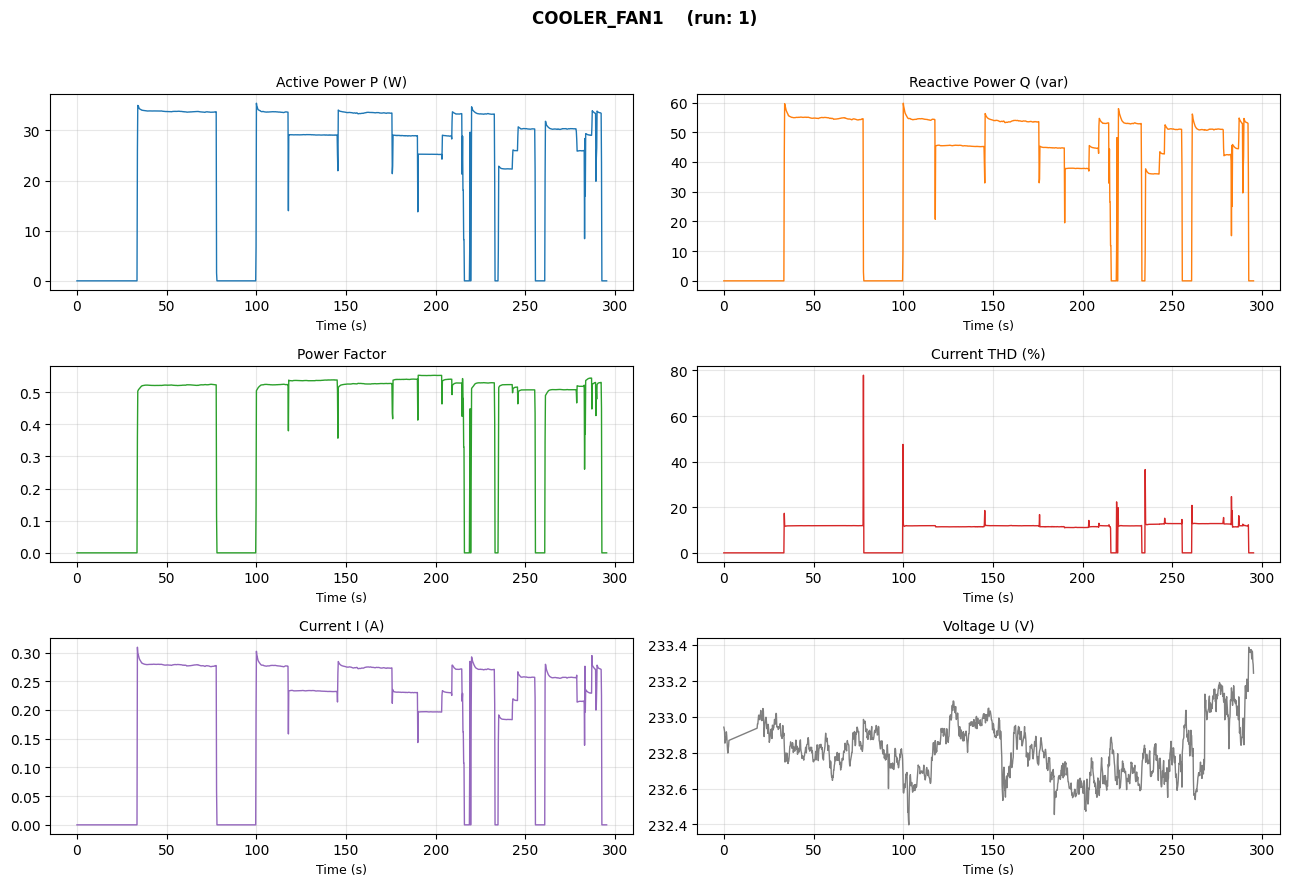

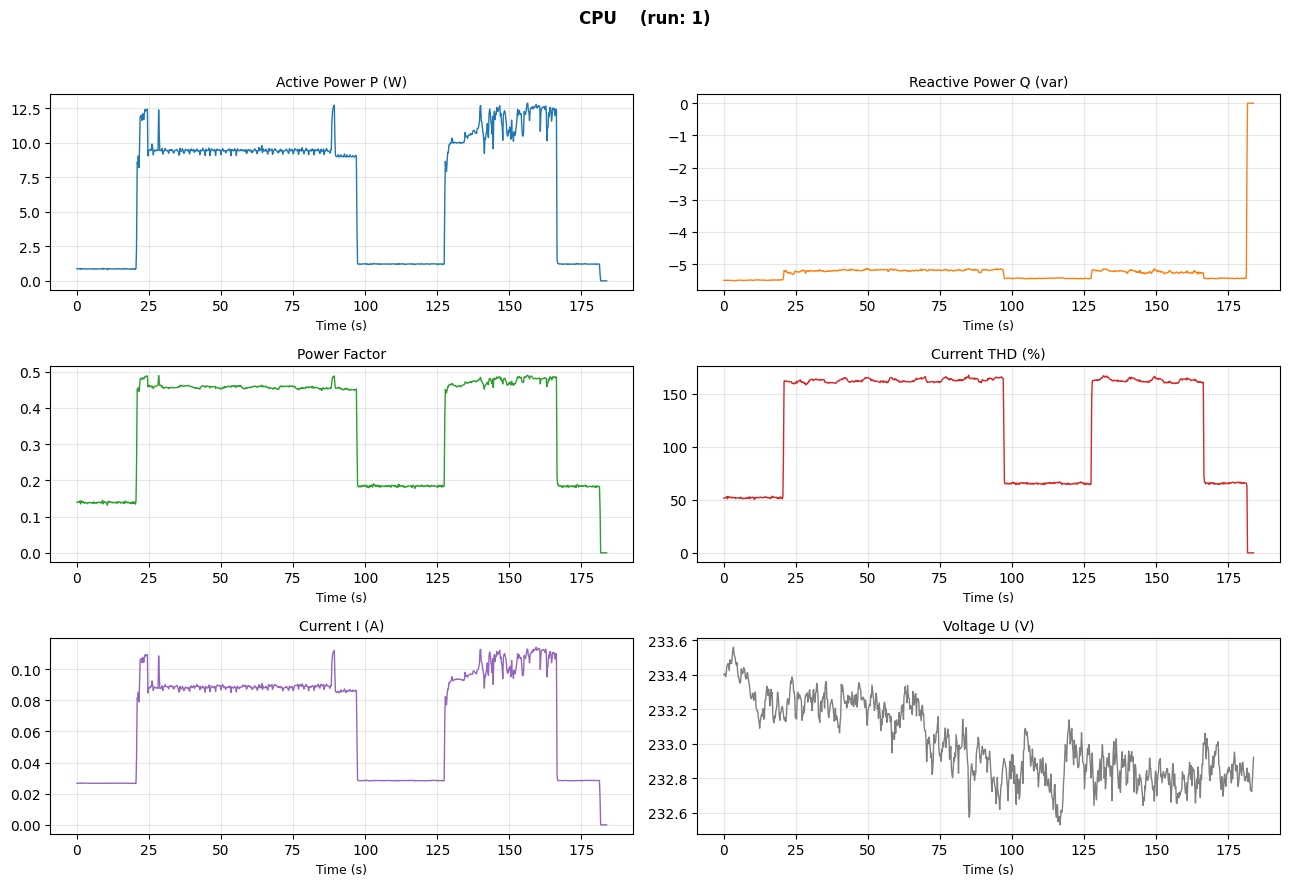

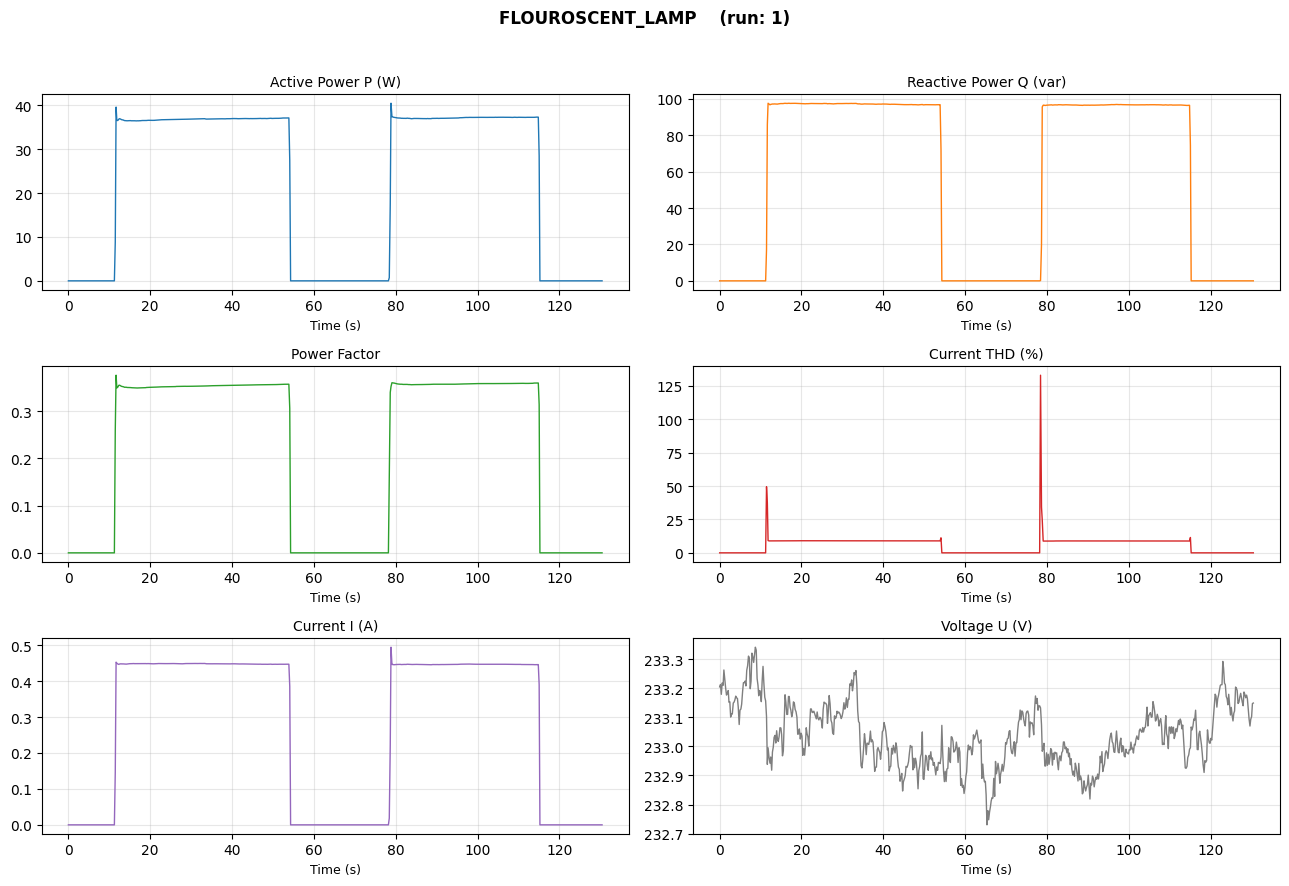

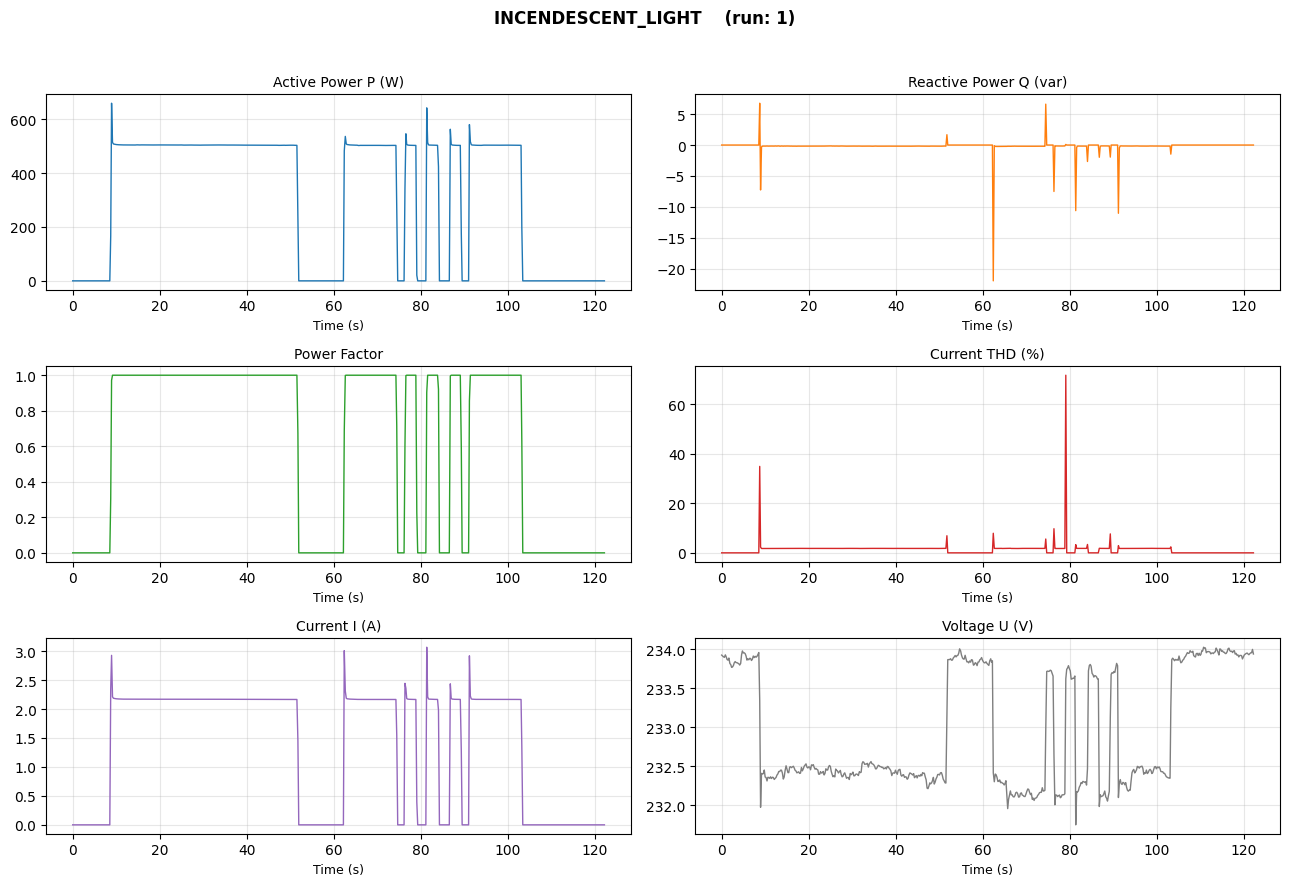

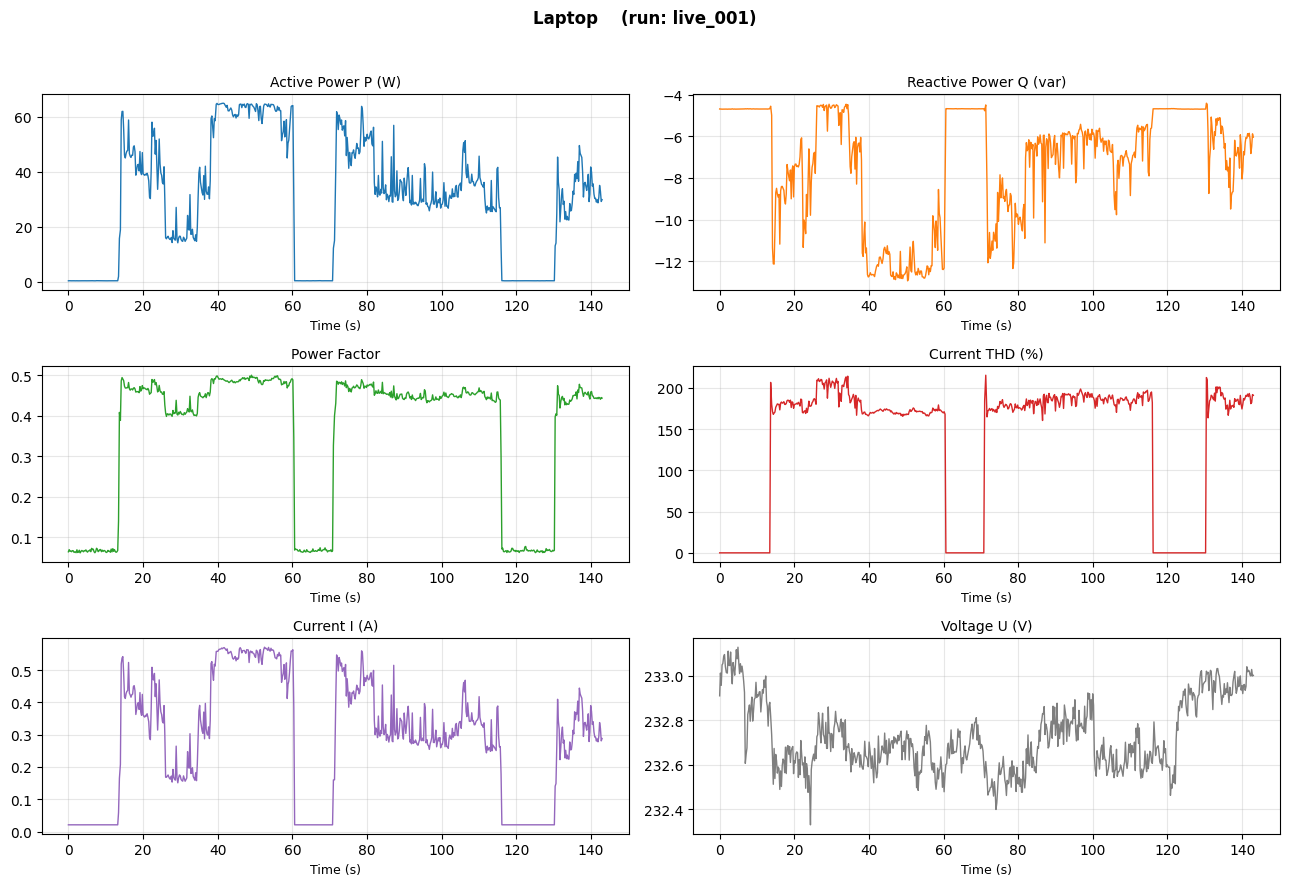

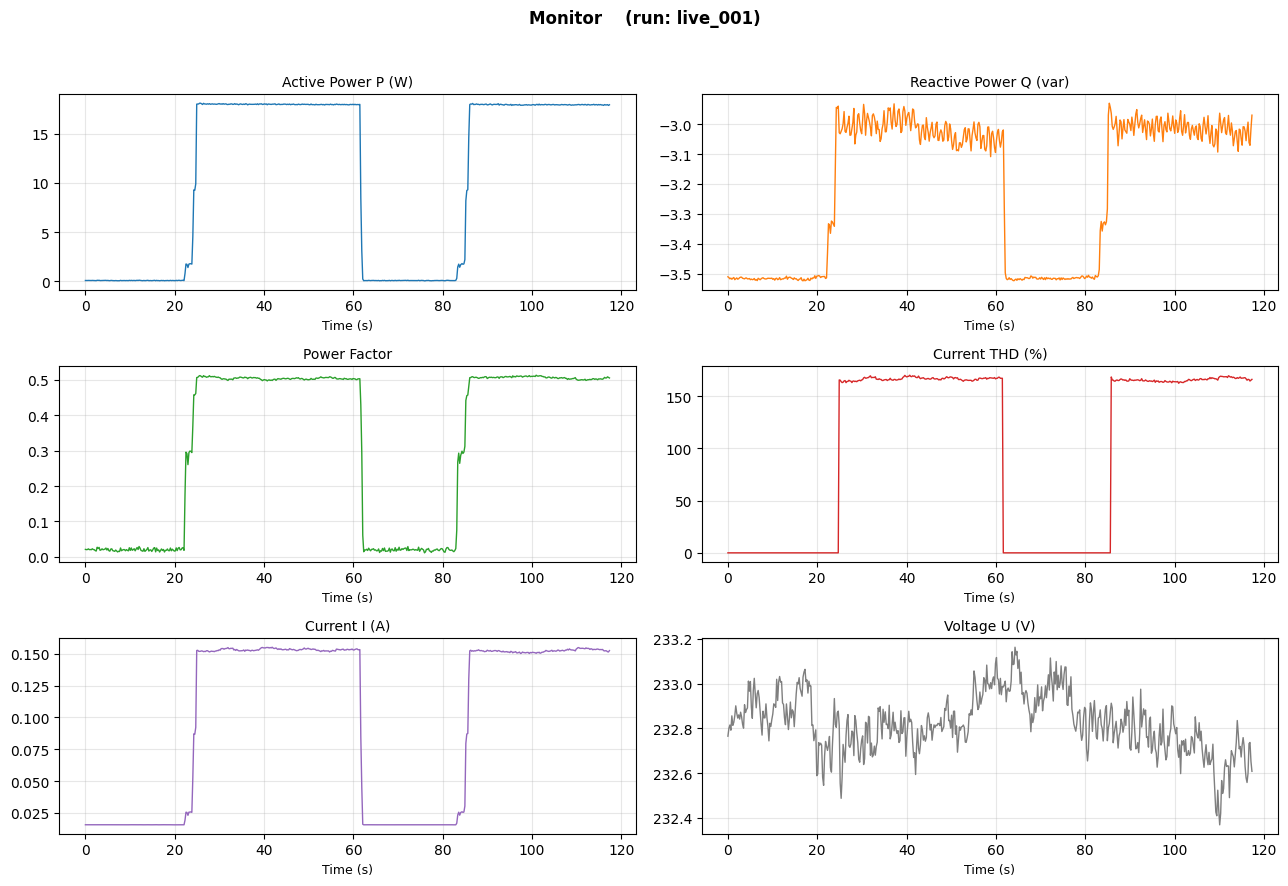

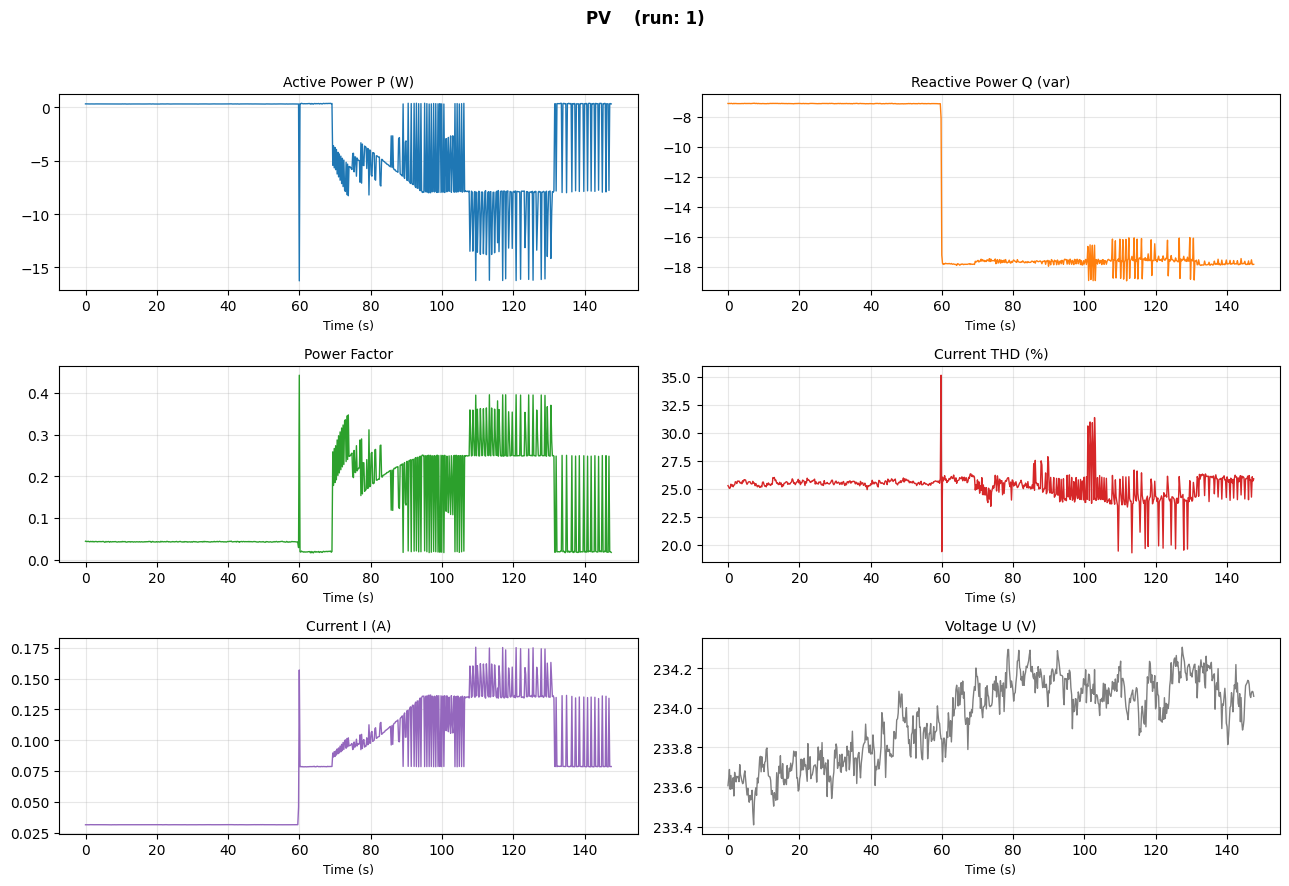

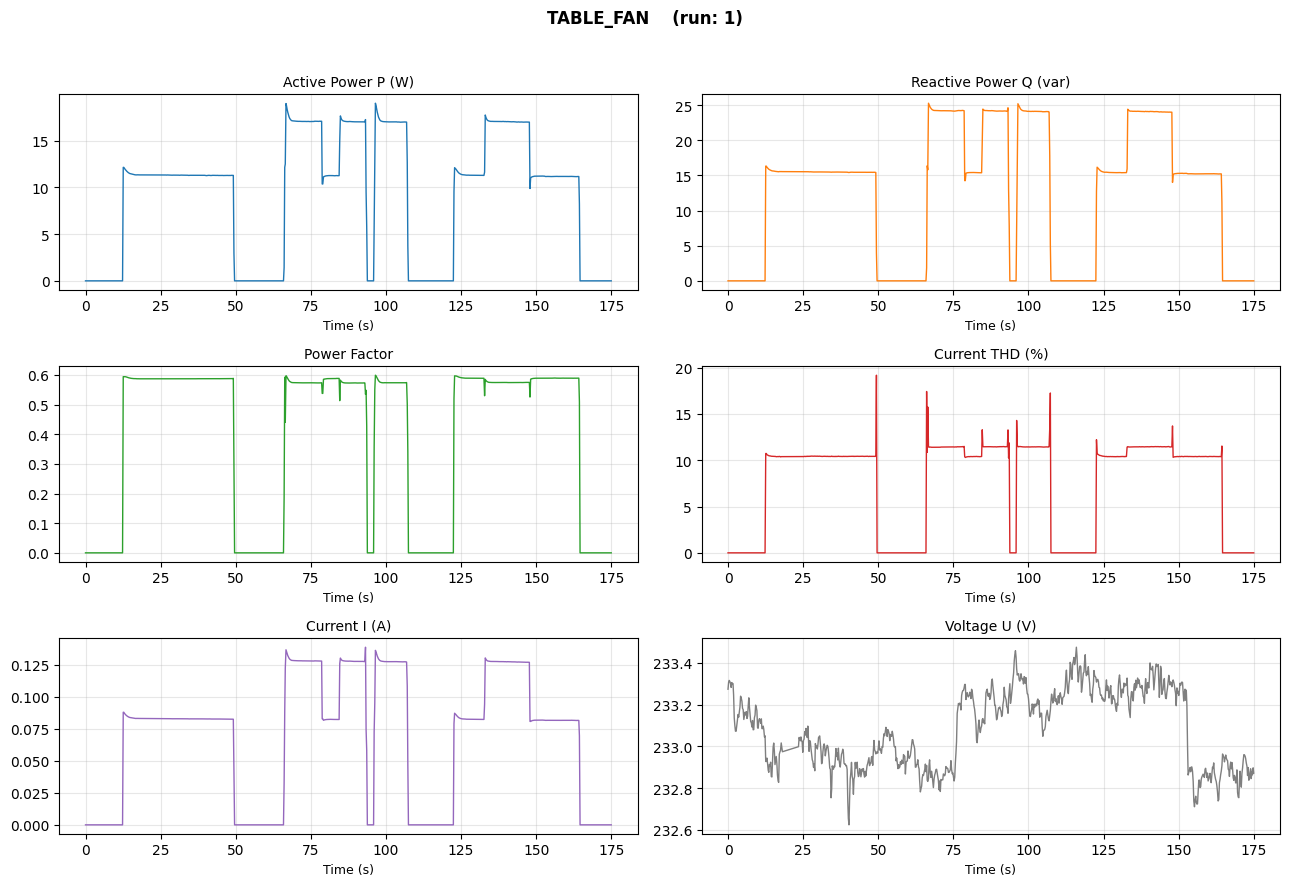

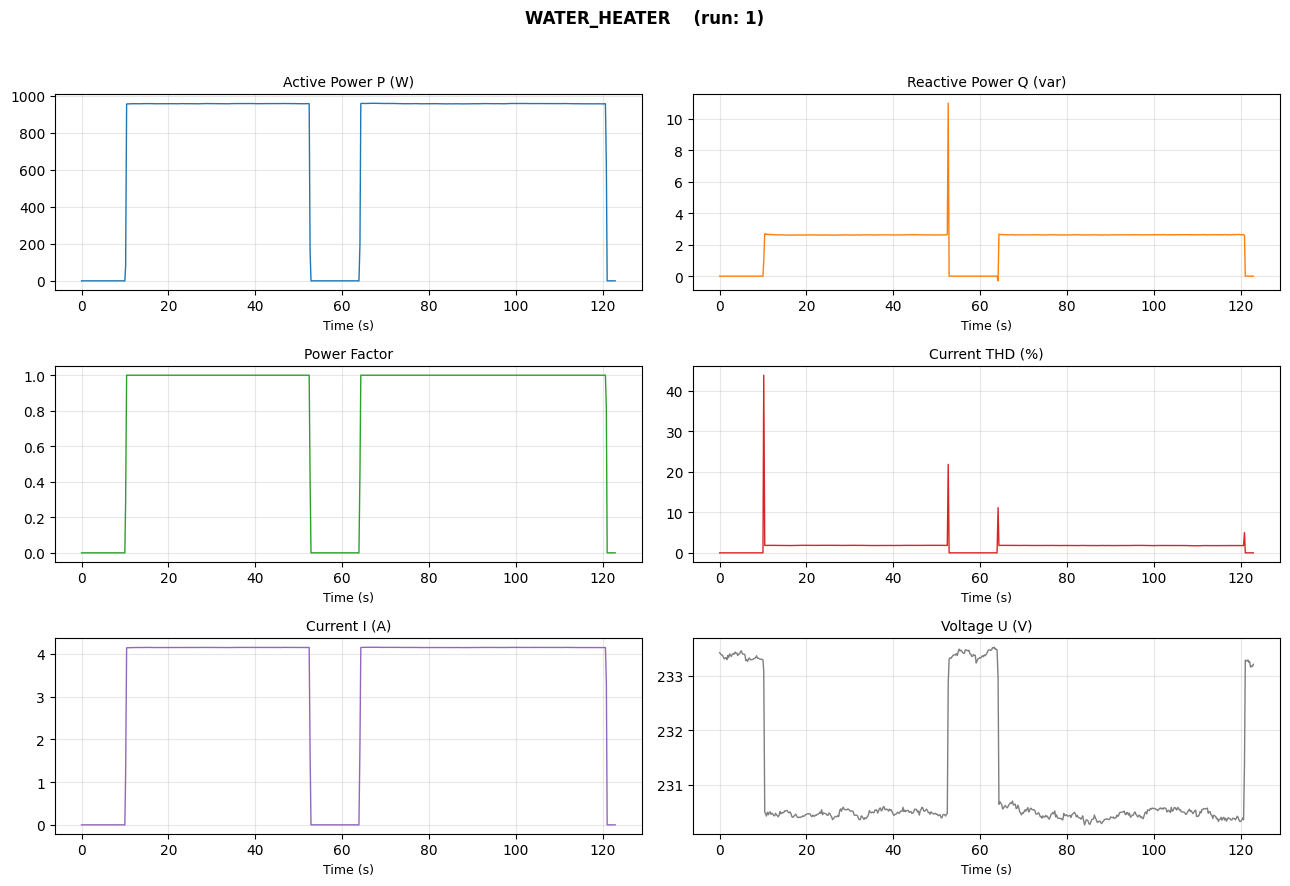

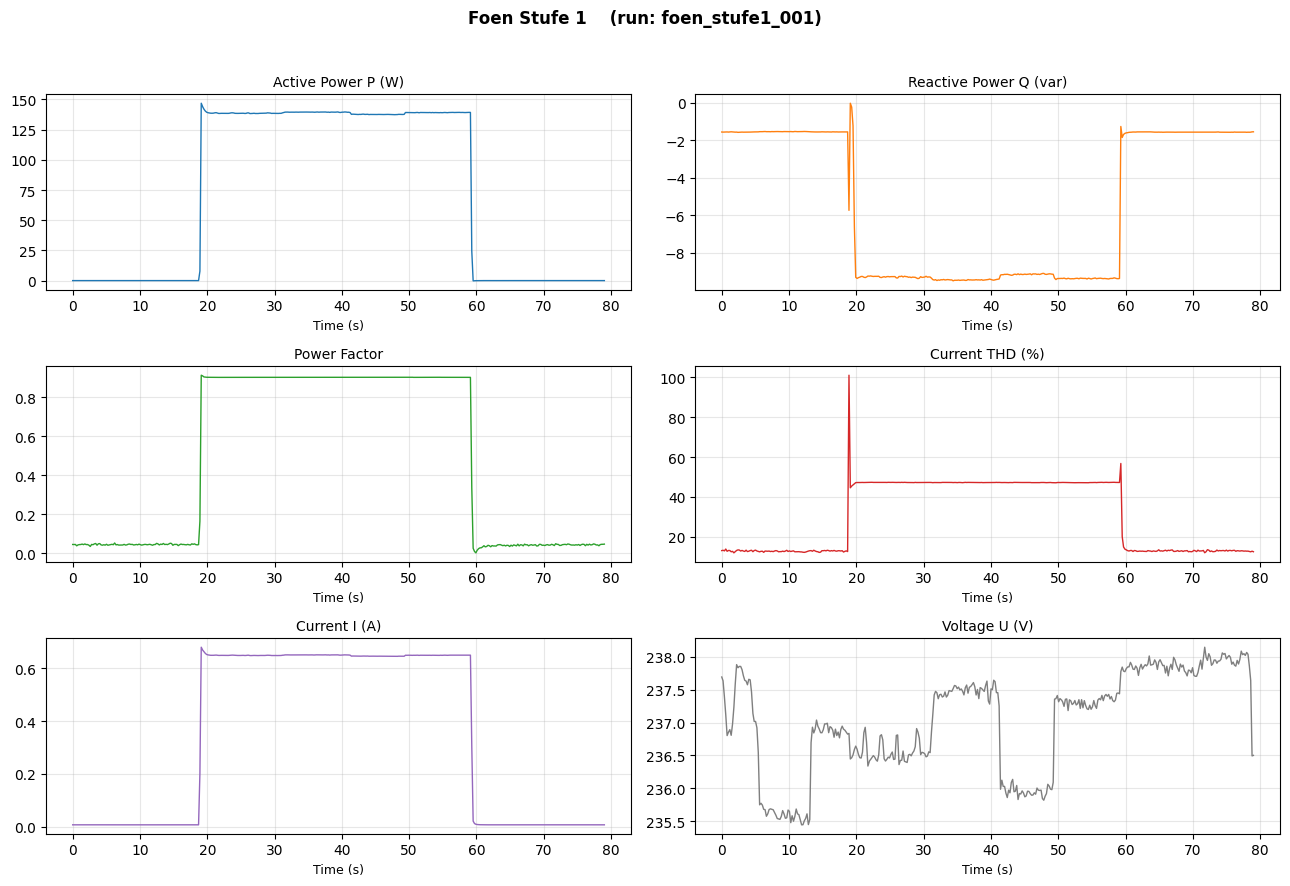

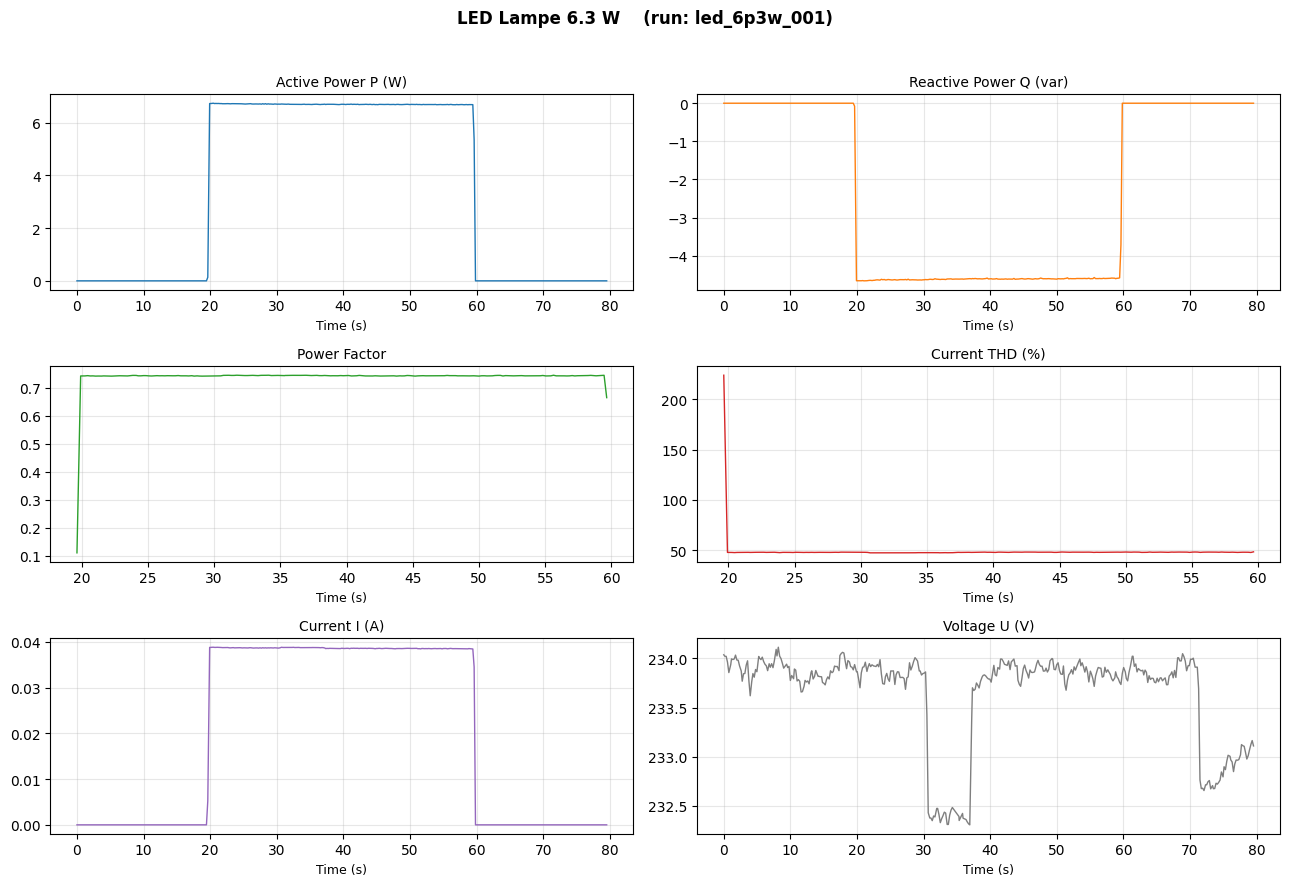

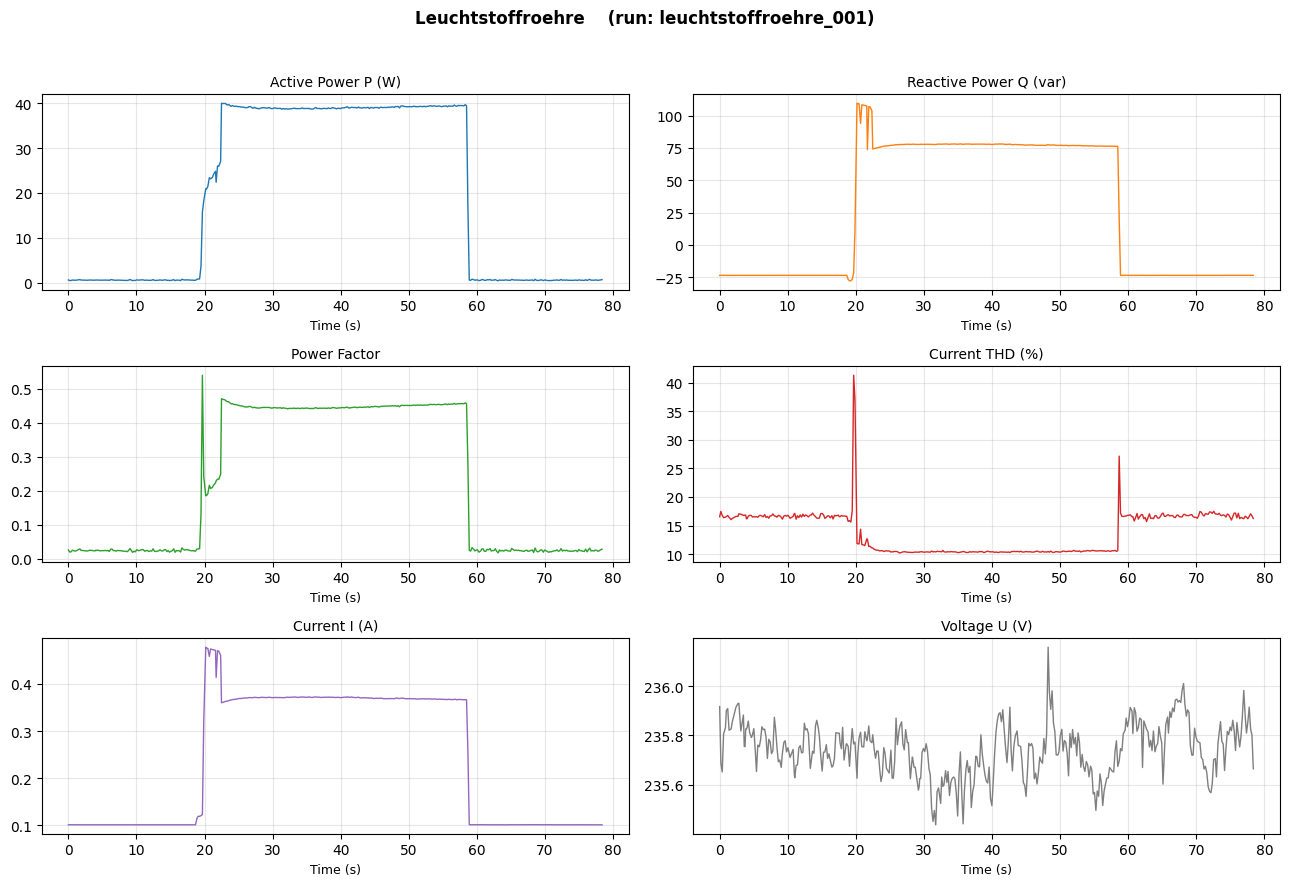

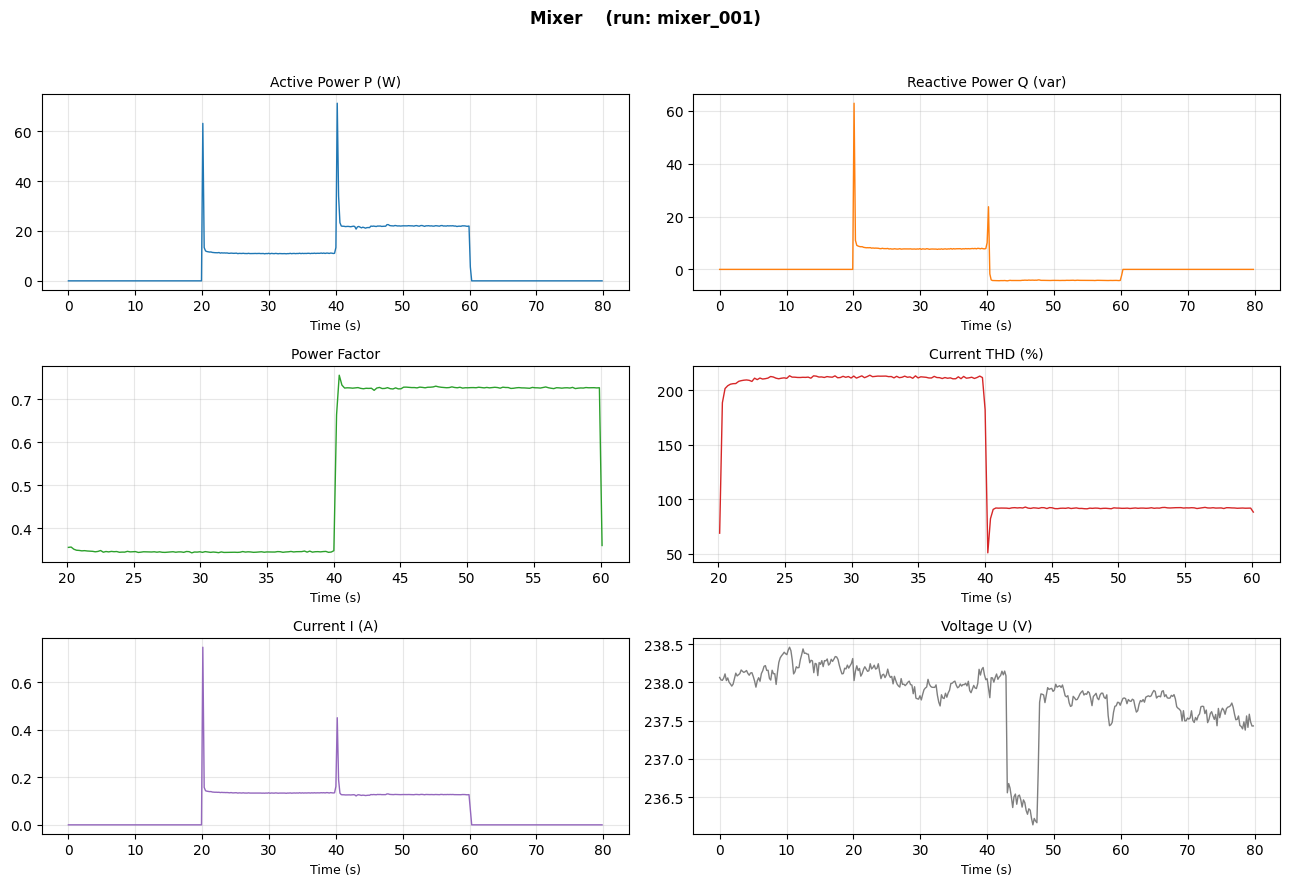

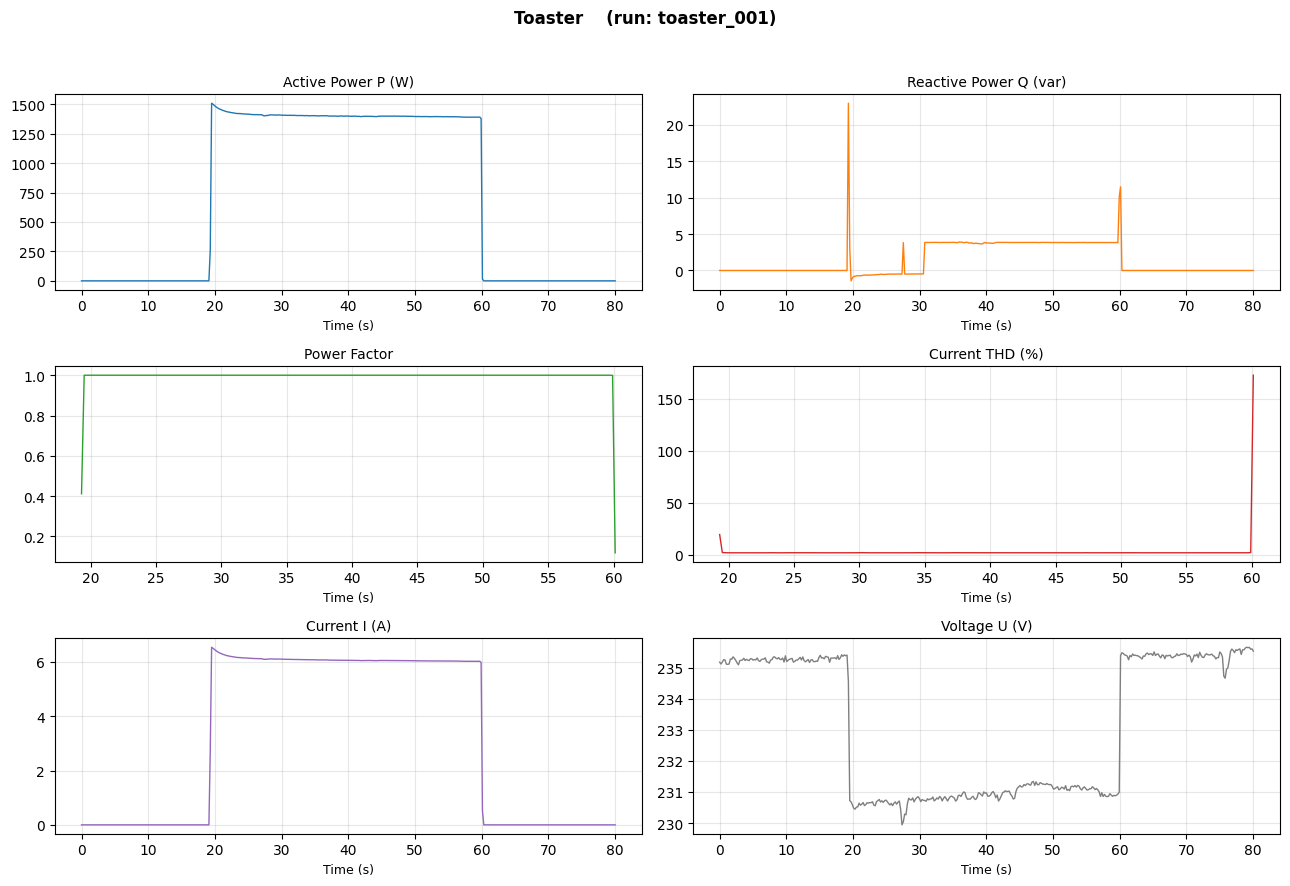

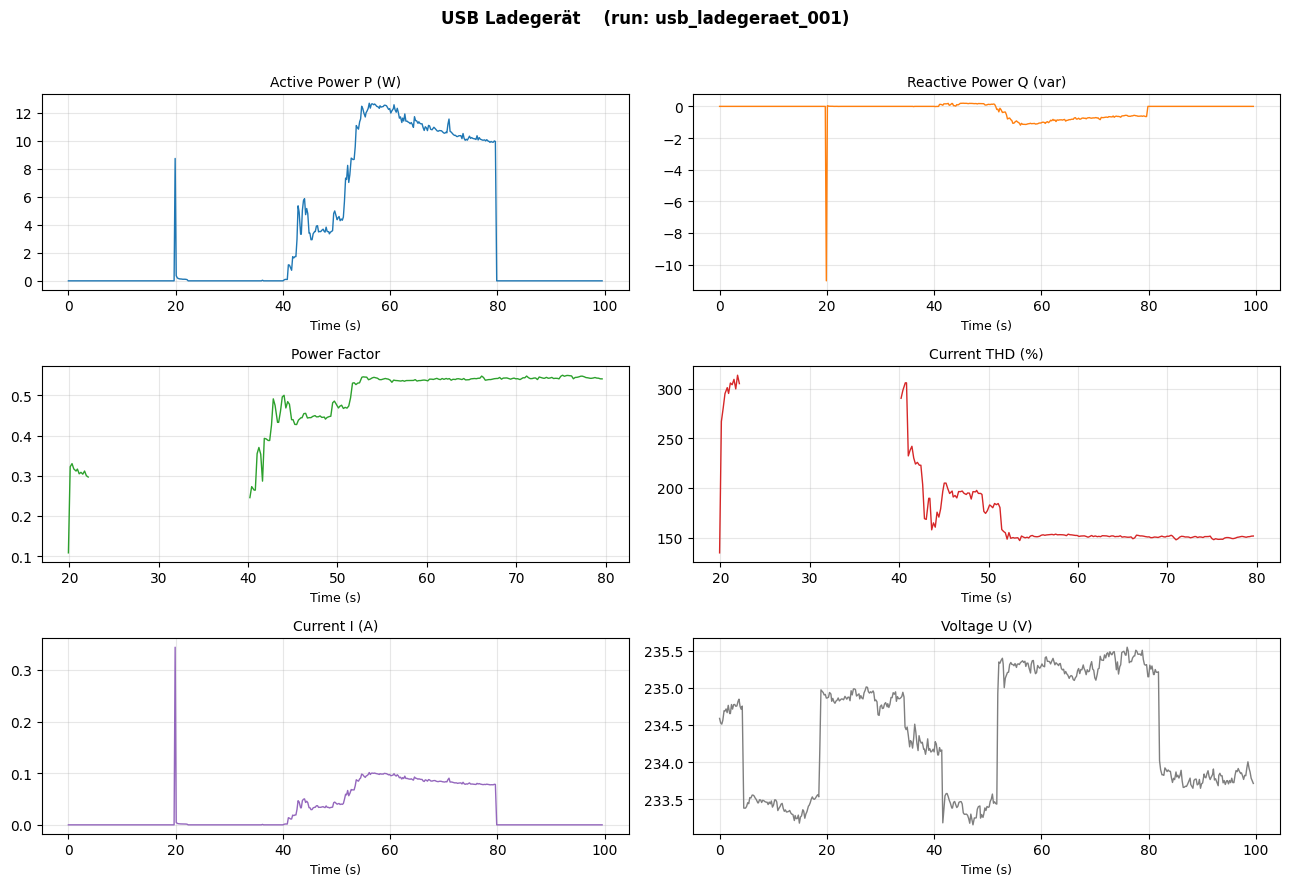

In [3]:
# one 6-channel figure per real appliance
import matplotlib.pyplot as plt
for device, path in registry.discover(include_excluded=True).items():
    fig = visualization.plot_run(path)
    plt.show()


## 3. Synthesizer

Generate **150 training + 50 test** runs per appliance from the measured fingerprints.
Every appliance uses a clean on/off step model except the Mixer (two-speed motor). Output
matches the real PAC4200 schema; off-state PF and THD are NaN. The real recordings are
never used for training - they are the held-out test set.


In [4]:
if REGENERATE_SYNTHETIC or not any(paths.SYNTH_TRAIN.glob("*.csv")):
    m_train, m_test = synthesizer.build_stage2(n_train=150, n_test=50)
    print(f"Generated {len(m_train)} training + {len(m_test)} test runs "
          f"({len(m_train)//150} appliances).")
else:
    print("Reusing existing synthetic data (set REGENERATE_SYNTHETIC=True to rebuild).")


Generated 2250 training + 750 test runs (15 appliances).


## 4. Verification

For each appliance × feature (P, Q, THD_i): does the real steady **mean** and **noise level**
fall inside the synthetic 5-95% band? Power factor is informational only (synthetic PF is
displacement-only and differs from the meter's true PF under high distortion).


In [5]:
verification_table = verification.build_stage3()
verification_table.head(20)

MILESTONE 1 - STAGE 3: VERIFICATION (15 appliances)
  [ok]   COFFEE_MACHINE
  [ok]   COOLER_FAN1
  [ok]   CPU
  [ok]   FLOUROSCENT_LAMP
  [ok]   INCENDESCENT_LIGHT
  [ok]   Laptop
  [ok]   Monitor
  [ok]   TABLE_FAN
  [ok]   WATER_HEATER
  [ok]   Foen Stufe 1
  [ok]   LED Lampe 6.3 W
  [ok]   Leuchtstoffroehre
  [ok]   Mixer
  [ok]   Toaster
  [ok]   USB Ladegerät

Mean-band check  (P, Q, THD_i): 44/45 pass
Noise-band check (P, Q, THD_i): 42/45 pass

3 feature(s) flagged:
  WATER_HEATER/q_total_var: mean_pass=True noise_pass=False
  Mixer/p_total_w: mean_pass=True noise_pass=False
  Toaster/thd_i_l1_percent: mean_pass=False noise_pass=False


,feature,real_mean,synth_mean_p05,synth_mean_p95,mean_pass,real_std,synth_std_p05,synth_std_p95,noise_pass,informational,device
0,p_total_w,1215.460,1119.089,1310.611,True,23.388,21.480,25.141,True,False,COFFEE_MACHINE
1,q_total_var,2.448,2.240,2.633,True,0.241,0.220,0.263,True,False,COFFEE_MACHINE
2,pf_total,1.000,1.000,1.000,False,0.005,0.000,0.000,False,True,COFFEE_MACHINE
3,thd_i_l1_percent,2.037,2.022,2.052,True,0.140,0.130,0.152,True,False,COFFEE_MACHINE
4,p_total_w,30.495,28.176,33.155,True,3.397,3.068,3.665,True,False,COOLER_FAN1
5,q_total_var,48.040,44.105,52.182,True,6.380,5.776,6.940,True,False,COOLER_FAN1
6,pf_total,0.531,0.491,0.578,True,0.019,0.057,0.073,False,True,COOLER_FAN1
7,thd_i_l1_percent,11.642,11.577,11.714,True,0.479,0.440,0.518,True,False,COOLER_FAN1
8,p_total_w,9.540,8.803,10.300,True,0.648,0.586,0.709,True,False,CPU
9,q_total_var,-5.196,-5.612,-4.817,True,0.028,0.025,0.030,True,False,CPU


Any flagged features are printed above. Expected flags with this appliance set:
Toaster THD, Mixer P-noise, Water Heater Q-noise - all documented synthesizer limitations,
not hidden failures. A handful of overlay figures are saved in `outputs/figures/`.


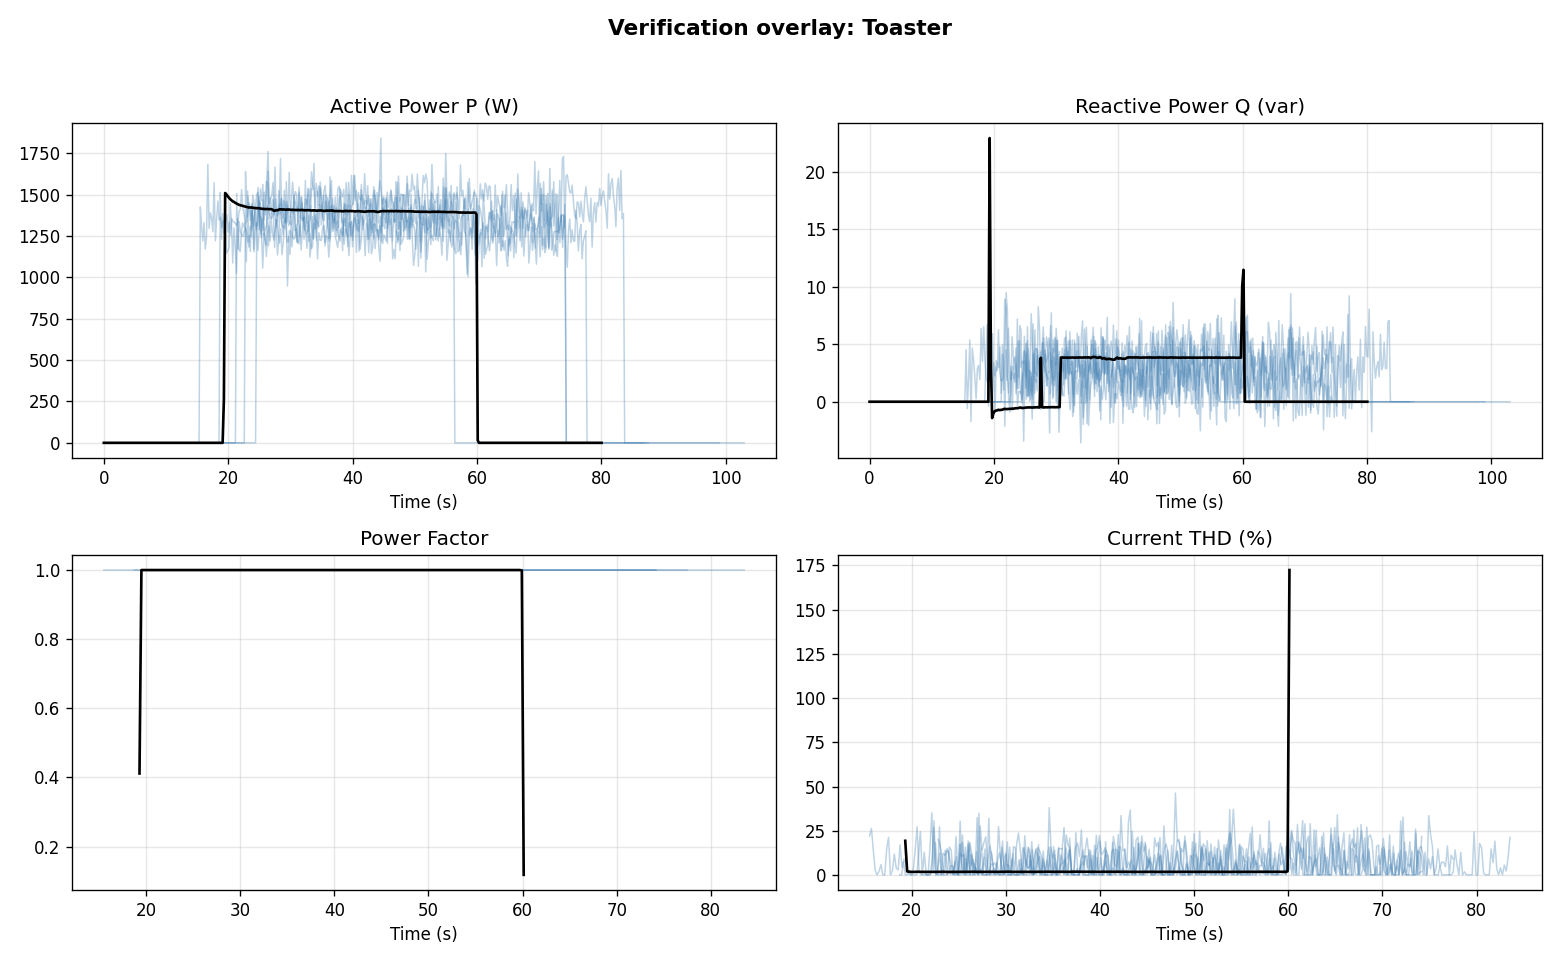

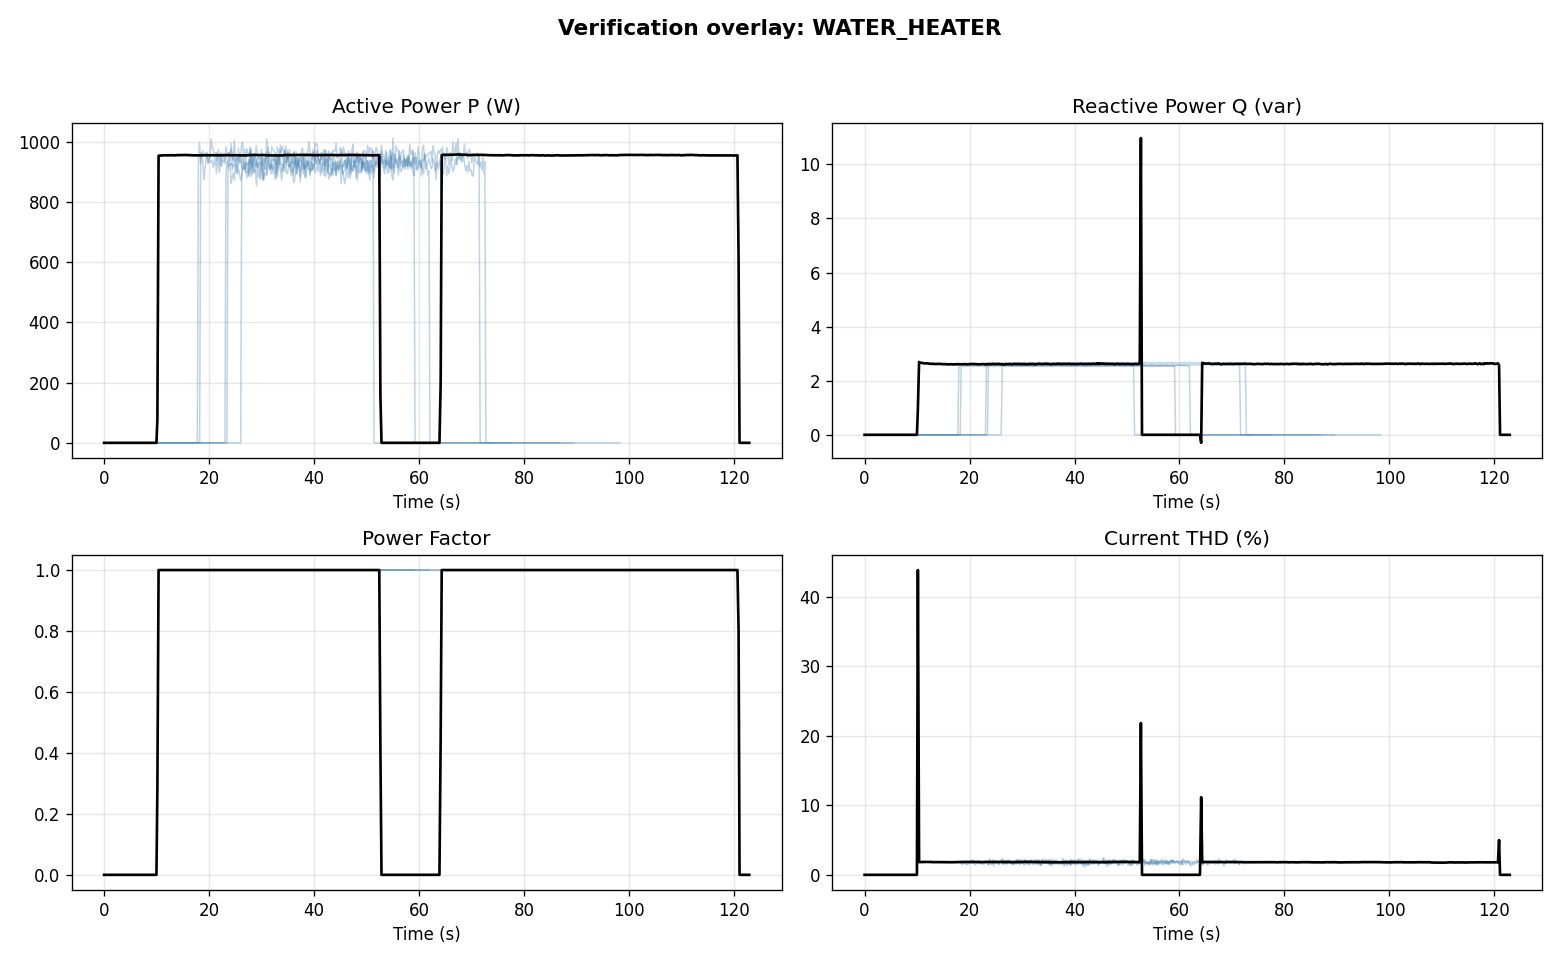

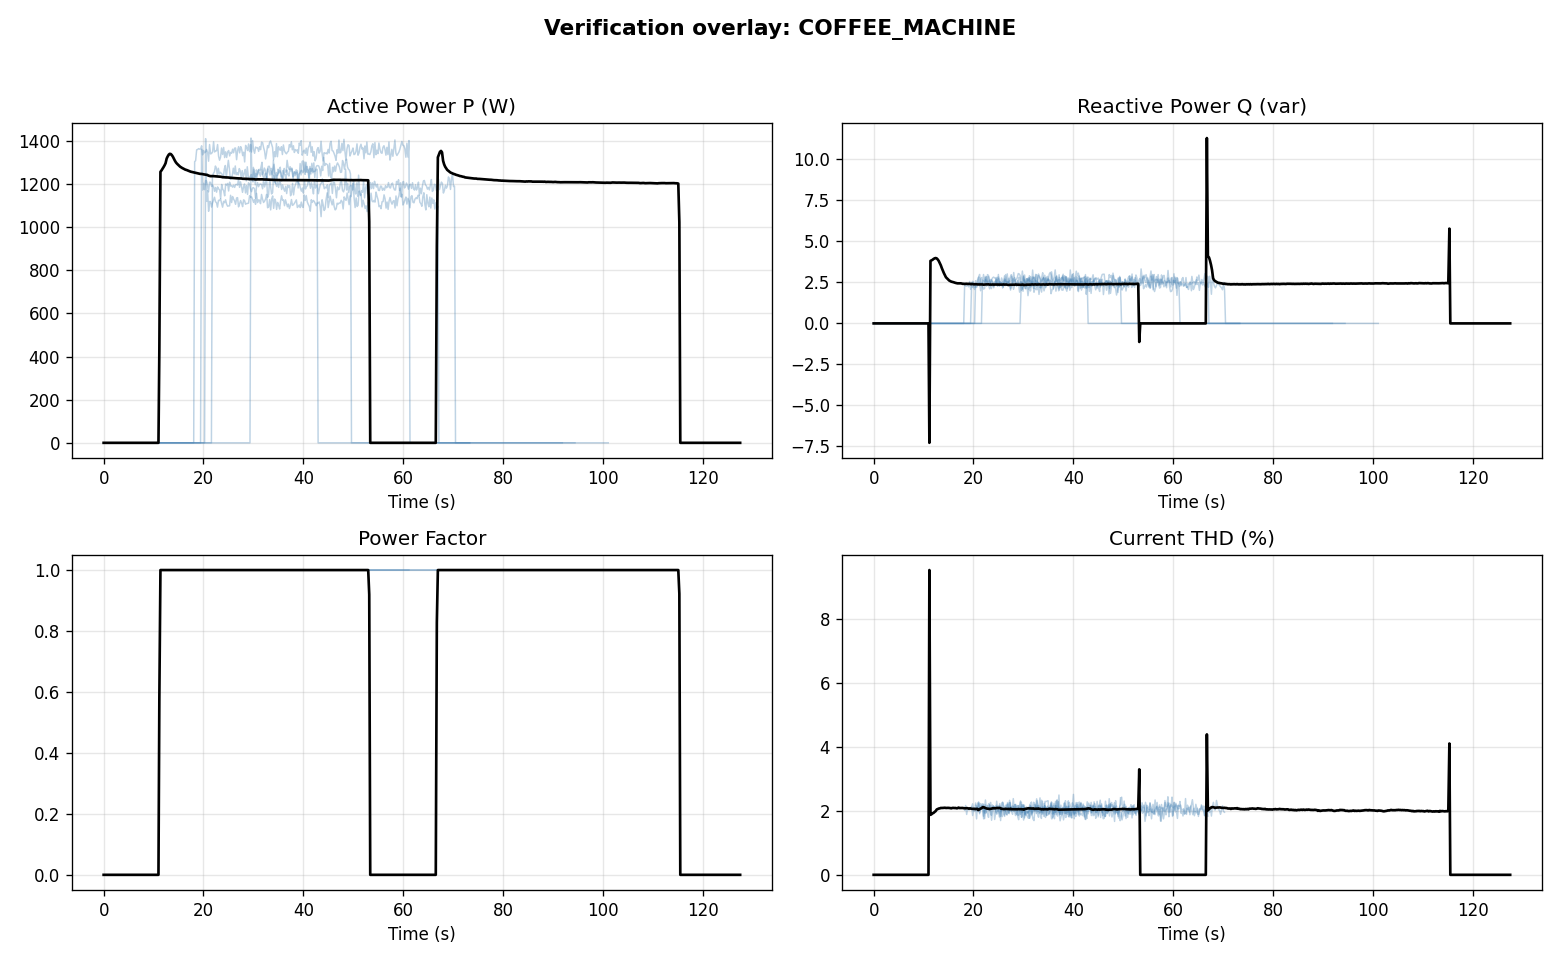

In [7]:
# show three verification overlays as examples
from IPython.display import Image
import matplotlib.pyplot as plt
for slug in ["toaster", "water_heater", "coffee_machine"]:
    p = paths.FIGURES / f"verification_{slug}.png"
    if p.exists():
        display(Image(filename=str(p)))


## 5. Milestone 1 Status

| Deliverable | Status |
|---|---|
| Acquisition (15 appliances, robust loader) | done |
| Understanding & per-device visualization | done |
| Synthesizer (measurement-based) | done |
| Verification (mean + noise band) | done |
| Data storage + synthesizer infrastructure | done |
| PV reserved for Milestone 3 | noted |

**Next: Milestone 2** - event detection (multi-cycle), feature extraction, clustering, and
classification on all 15 appliances. The two hard pairs (fluorescents, CPU/USB) are the
appliances to watch.
